In [1]:
print("hello")

hello


In [37]:
def colab_install(lib, wheel_dir="/content/drive/MyDrive/colab_wheels"):
    import os, subprocess
    from google.colab import drive

    # Mount drive if needed
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")

    os.makedirs(wheel_dir, exist_ok=True)

    # Check cached wheels
    cached = any(
        f.lower().startswith(lib.lower().replace("-", "_"))
        for f in os.listdir(wheel_dir)
    )

    # Download if missing
    if not cached:
        print(f"Downloading wheels for {lib}")
        subprocess.run(["pip", "download", lib, "-d", wheel_dir])

    # Install from cache
    print(f"Installing {lib}")
    subprocess.run([
        "pip", "install",
        "--no-index",
        f"--find-links={wheel_dir}",
        lib
    ])

    print("Done")


In [10]:
#Importing the Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Key Characteristics

Content: 10,000 medium seize images of Setellite Images of Land Use


Image Specs: Each image is 64x64 pixels, RGB Channel , and centered in a fixed-size frame.


In [12]:
import numpy as np
X = np.load('/content/drive/MyDrive/LandUseClassification_CNN/IMG_Matrix_RGB.npy')
print(X.shape)
X

(10000, 64, 64, 3)


array([[[[149, 121, 120],
         [149, 121, 120],
         [148, 119, 121],
         ...,
         [102,  90, 100],
         [104,  92, 102],
         [103,  91, 101]],

        [[149, 121, 120],
         [149, 121, 120],
         [148, 119, 121],
         ...,
         [102,  90, 100],
         [104,  92, 102],
         [103,  91, 101]],

        [[143, 117, 118],
         [142, 116, 117],
         [146, 117, 121],
         ...,
         [102,  92, 101],
         [102,  90, 100],
         [103,  91, 101]],

        ...,

        [[144, 116, 115],
         [141, 117, 117],
         [137, 117, 119],
         ...,
         [103,  93, 102],
         [100,  90, 101],
         [101,  91, 102]],

        [[132, 110, 113],
         [132, 112, 114],
         [127, 110, 116],
         ...,
         [105,  94, 102],
         [105,  93, 103],
         [107,  95, 105]],

        [[124, 105, 109],
         [122, 106, 109],
         [120, 103, 111],
         ...,
         [106,  95, 103],
        

In [13]:
y =  np.load('/content/drive/MyDrive/LandUseClassification_CNN/Label_RGB.npy', allow_pickle=True)
print(y.shape)
y

(10000,)


array(['AnnualCrop', 'AnnualCrop', 'AnnualCrop', ..., 'SeaLake',
       'SeaLake', 'SeaLake'], dtype='<U20')

(10000, 64, 64, 3)


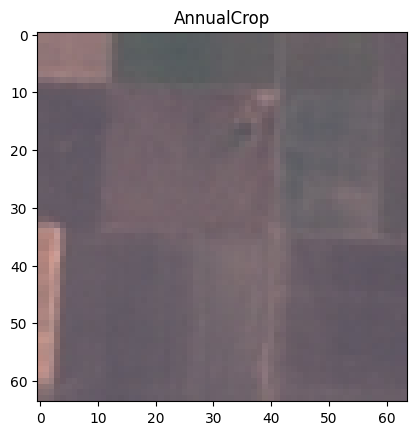

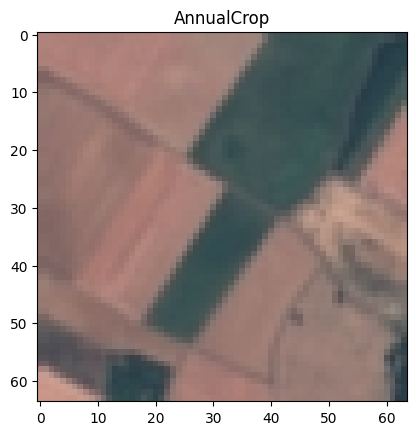

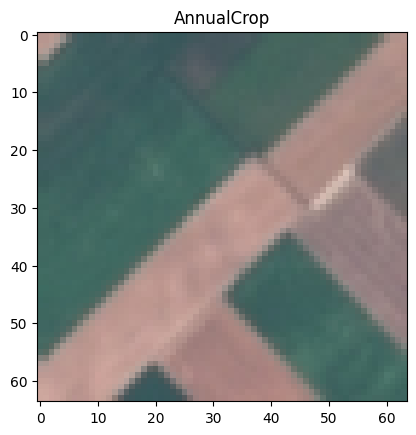

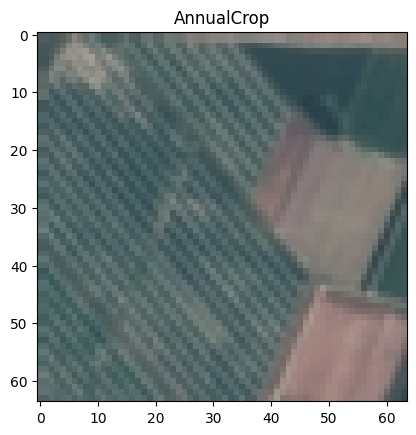

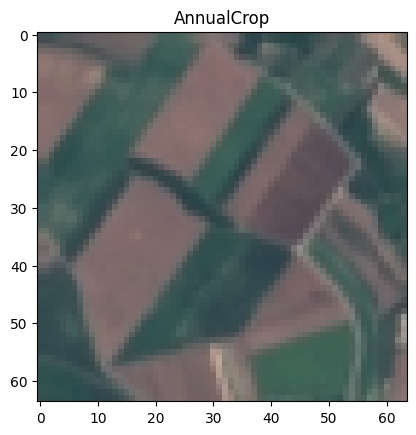

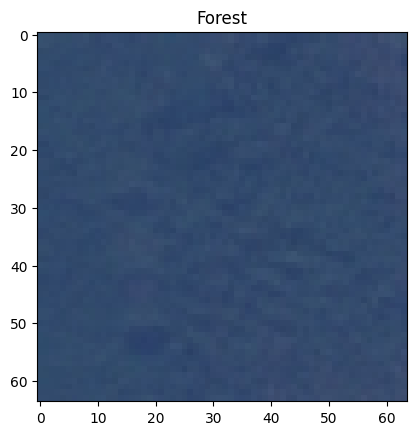

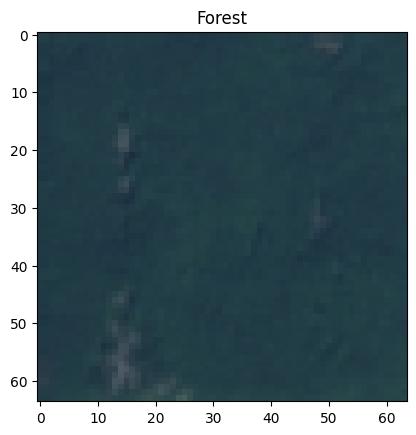

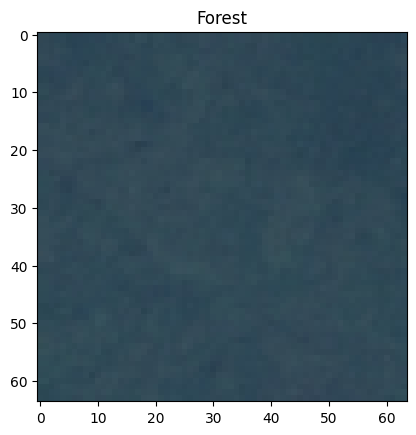

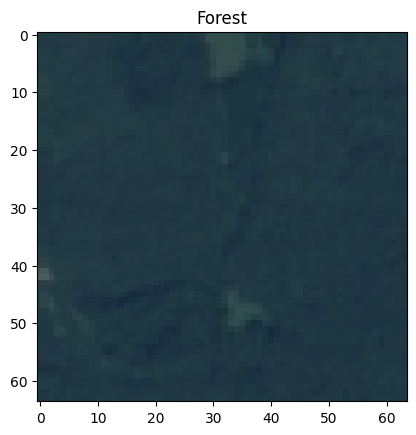

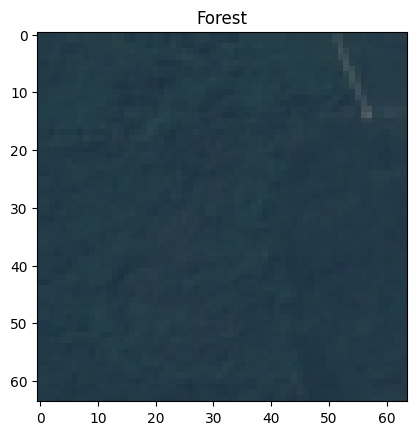

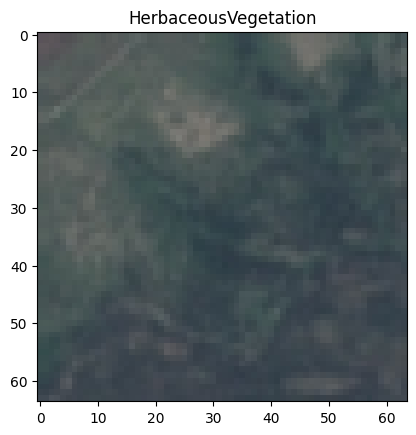

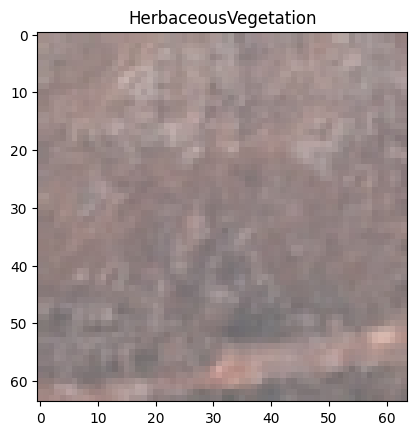

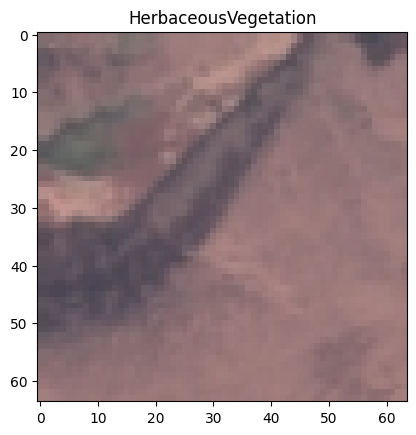

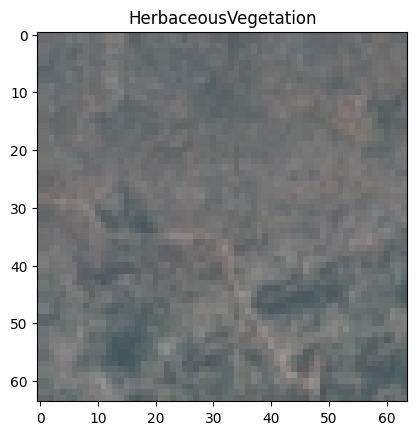

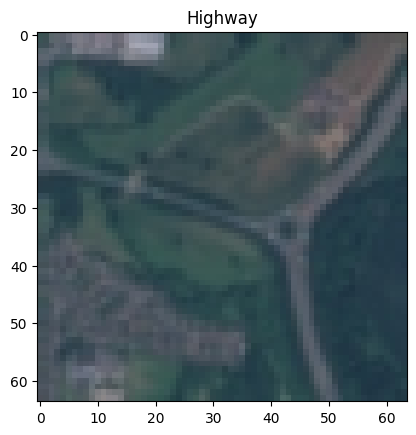

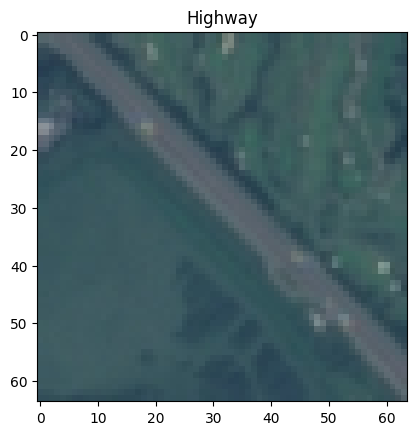

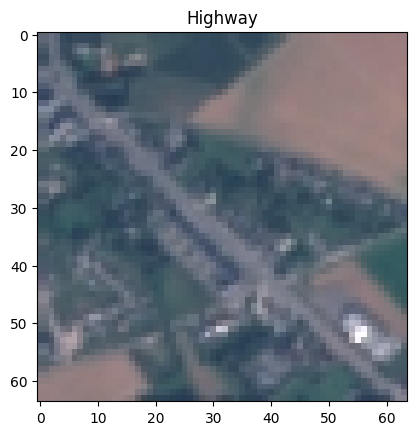

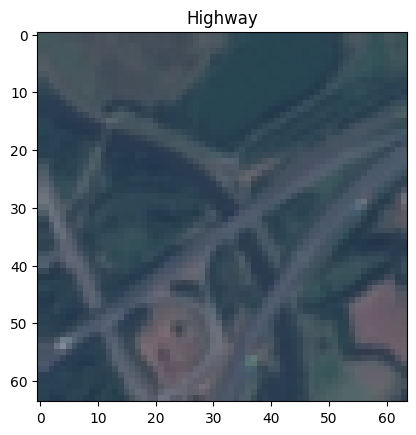

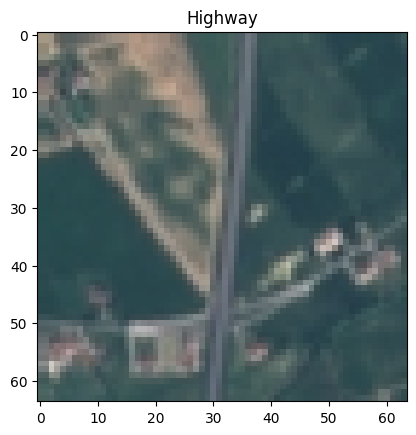

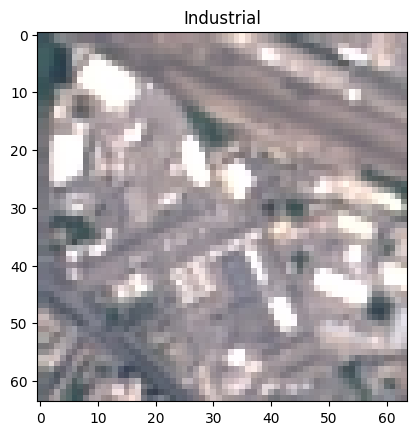

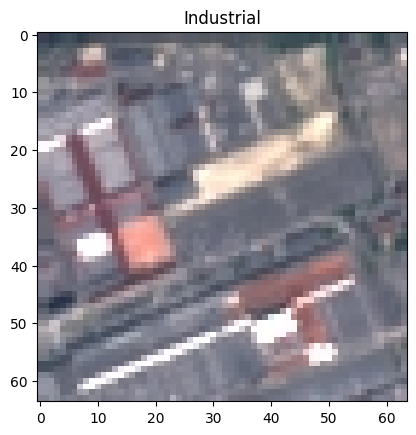

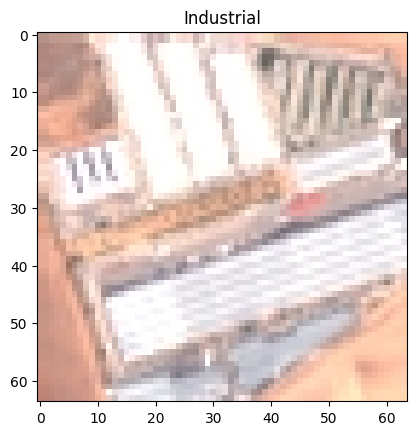

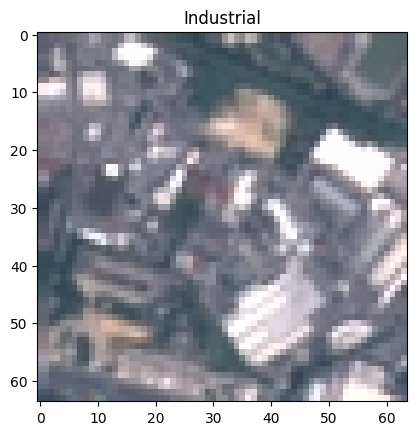

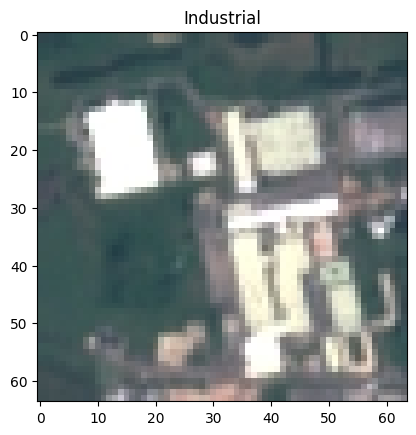

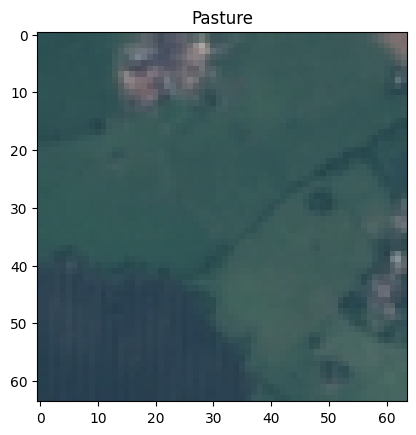

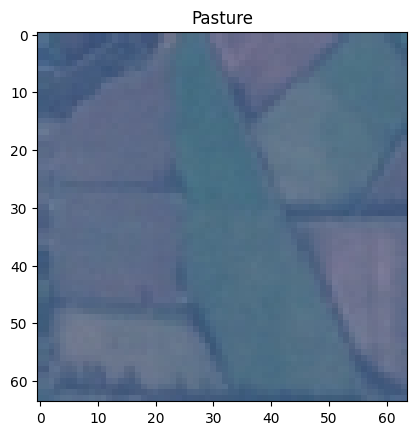

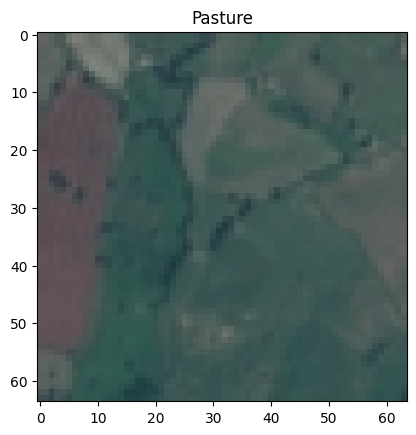

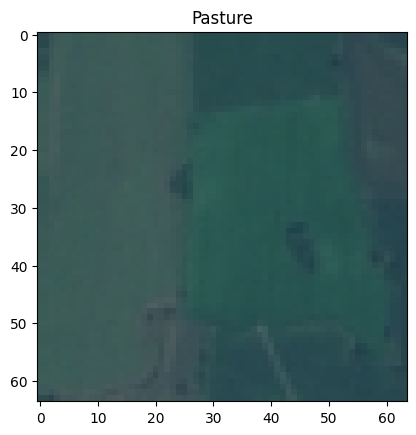

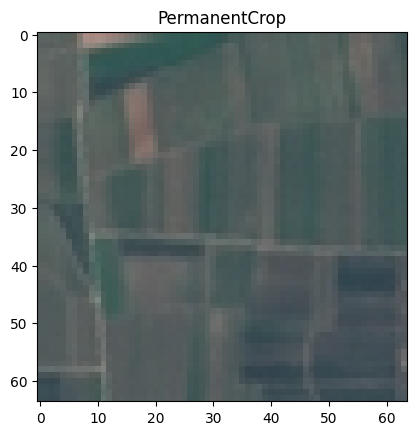

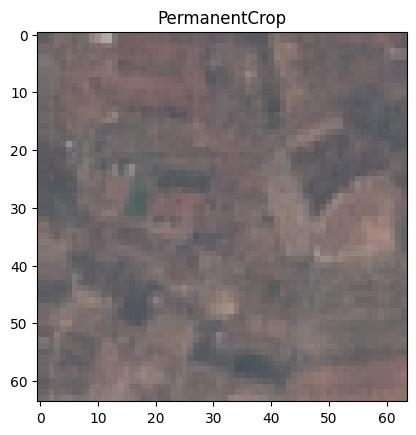

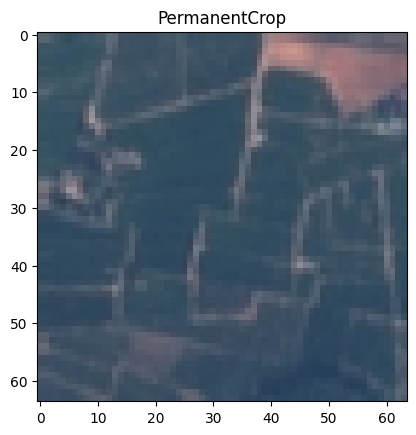

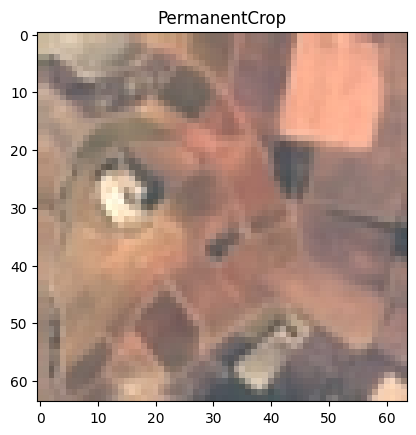

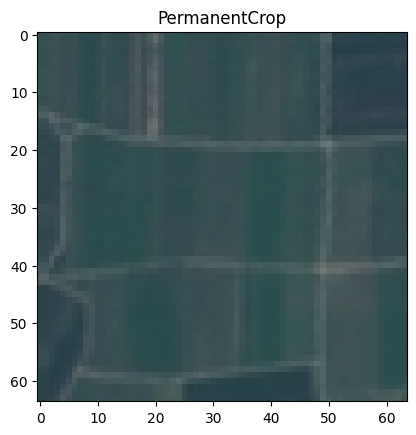

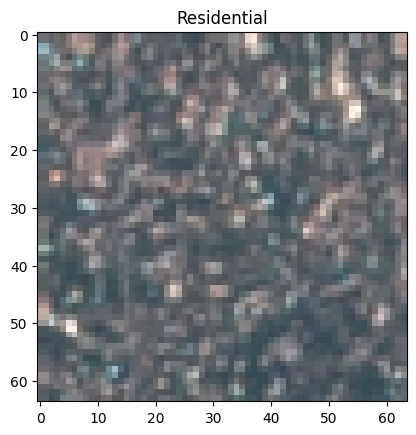

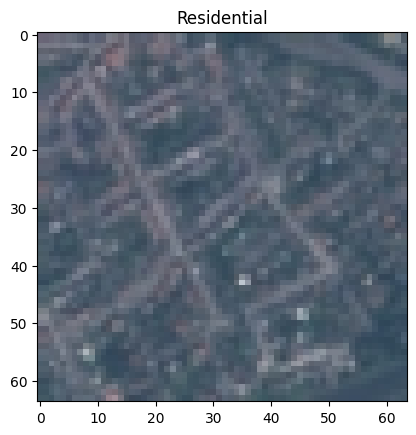

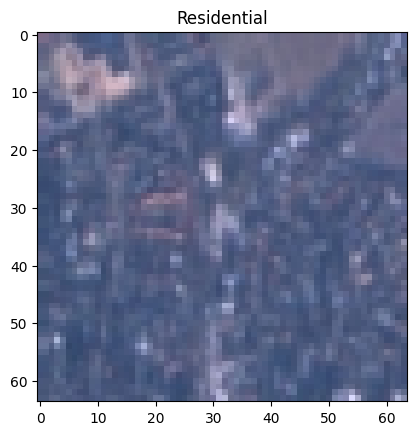

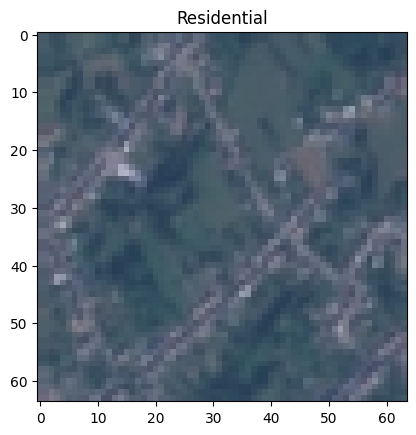

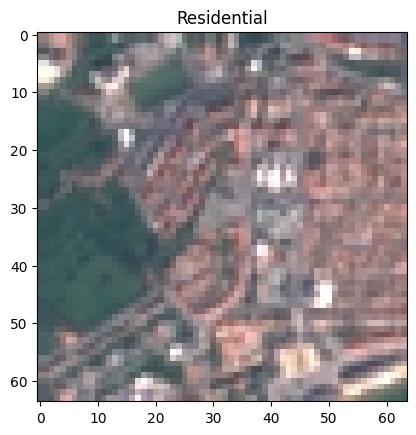

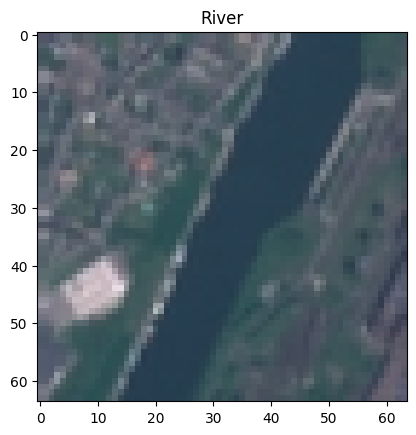

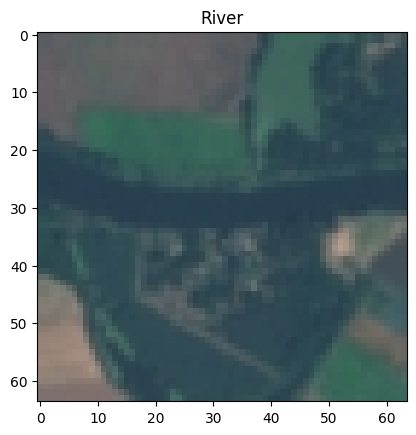

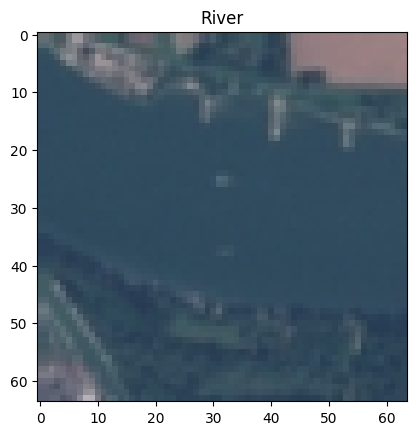

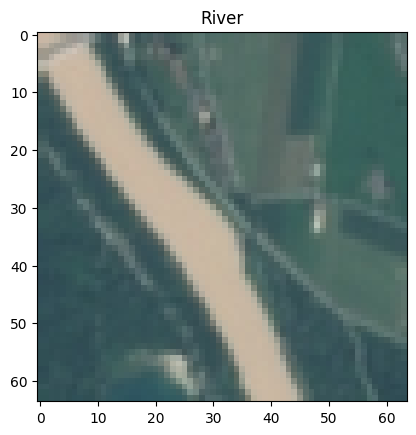

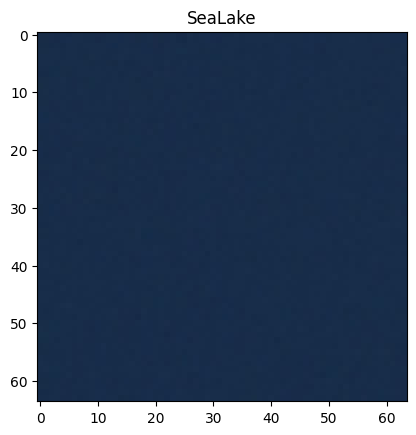

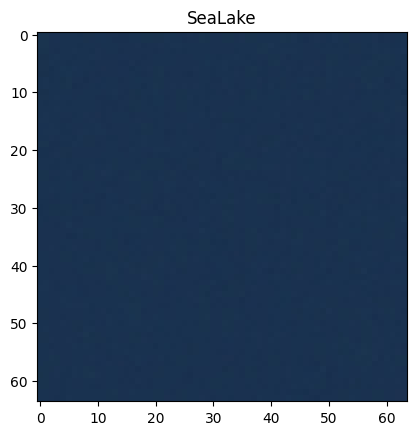

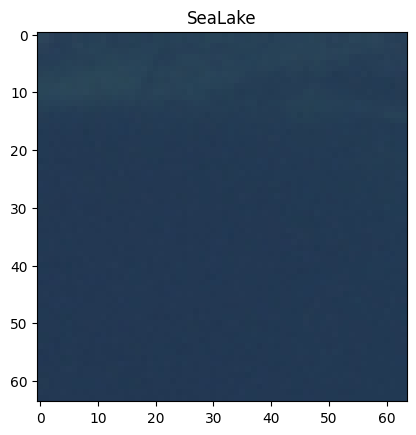

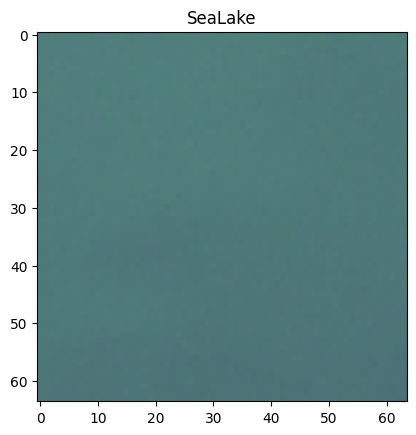

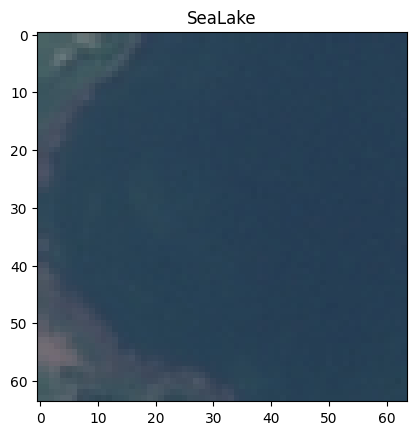

In [14]:
print(X.shape)
import matplotlib.pyplot as plt
for i in range(0,X.shape[0],215):
  plt.imshow(X[i], cmap='gray')
  plt.title(f"{y[i]}")
  plt.show()



(10000, 64, 64, 3)


array([[[149, 121, 120],
        [149, 121, 120],
        [148, 119, 121],
        ...,
        [102,  90, 100],
        [104,  92, 102],
        [103,  91, 101]],

       [[149, 121, 120],
        [149, 121, 120],
        [148, 119, 121],
        ...,
        [102,  90, 100],
        [104,  92, 102],
        [103,  91, 101]],

       [[143, 117, 118],
        [142, 116, 117],
        [146, 117, 121],
        ...,
        [102,  92, 101],
        [102,  90, 100],
        [103,  91, 101]],

       ...,

       [[144, 116, 115],
        [141, 117, 117],
        [137, 117, 119],
        ...,
        [103,  93, 102],
        [100,  90, 101],
        [101,  91, 102]],

       [[132, 110, 113],
        [132, 112, 114],
        [127, 110, 116],
        ...,
        [105,  94, 102],
        [105,  93, 103],
        [107,  95, 105]],

       [[124, 105, 109],
        [122, 106, 109],
        [120, 103, 111],
        ...,
        [106,  95, 103],
        [106,  94, 104],
        [107,  95, 105]]], dtype=uint8)
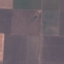

In [15]:
print(X.shape)
X[0]

In [16]:
# Normalize pixel values
X = X / 255.0

In [17]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded

#Note this are integer labels i.e 2>1 but since the original label are not ordinal we would have to use     loss='sparse_categorical_crossentropy',
#which tells the CNN model the there is not any order in labels


array([0, 0, 0, ..., 9, 9, 9])

In [18]:
from sklearn.model_selection import train_test_split
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [19]:
print(X_train.shape)
X_train

(8000, 64, 64, 3)


array([[[[0.32156863, 0.45490196, 0.45098039],
         [0.32156863, 0.45490196, 0.45098039],
         [0.32941176, 0.44705882, 0.45490196],
         ...,
         [0.31764706, 0.45098039, 0.44705882],
         [0.32941176, 0.45098039, 0.45882353],
         [0.32156863, 0.44313725, 0.45098039]],

        [[0.32156863, 0.45490196, 0.45098039],
         [0.32941176, 0.45490196, 0.45098039],
         [0.33333333, 0.45098039, 0.45882353],
         ...,
         [0.31764706, 0.45098039, 0.44705882],
         [0.32941176, 0.45098039, 0.45882353],
         [0.3254902 , 0.44705882, 0.45490196]],

        [[0.32941176, 0.45490196, 0.45098039],
         [0.32941176, 0.45490196, 0.45098039],
         [0.3372549 , 0.45490196, 0.45490196],
         ...,
         [0.32941176, 0.45490196, 0.45098039],
         [0.3254902 , 0.44705882, 0.45490196],
         [0.3254902 , 0.44705882, 0.45490196]],

        ...,

        [[0.32156863, 0.43921569, 0.44705882],
         [0.31764706, 0.43529412, 0.44313725]

In [20]:
print(y_train.shape)
y_train

(8000,)


array([9, 1, 1, ..., 5, 0, 7])

In [21]:
print(X_test.shape)
X_test

(2000, 64, 64, 3)


array([[[[0.58431373, 0.52156863, 0.47058824],
         [0.58823529, 0.51764706, 0.47058824],
         [0.59607843, 0.50196078, 0.4627451 ],
         ...,
         [0.74509804, 0.6745098 , 0.59607843],
         [0.6745098 , 0.61568627, 0.54117647],
         [0.59607843, 0.55294118, 0.48235294]],

        [[0.58823529, 0.51764706, 0.4627451 ],
         [0.58823529, 0.51764706, 0.4627451 ],
         [0.59607843, 0.50196078, 0.4627451 ],
         ...,
         [0.74901961, 0.67843137, 0.59215686],
         [0.6745098 , 0.61568627, 0.53333333],
         [0.6       , 0.54901961, 0.4745098 ]],

        [[0.61568627, 0.54117647, 0.48235294],
         [0.61568627, 0.54117647, 0.48235294],
         [0.6       , 0.51372549, 0.4627451 ],
         ...,
         [0.69019608, 0.62745098, 0.52941176],
         [0.69019608, 0.62745098, 0.5372549 ],
         [0.67058824, 0.61176471, 0.52156863]],

        ...,

        [[0.65490196, 0.57254902, 0.49803922],
         [0.65490196, 0.57254902, 0.49803922]

In [22]:
print(y_test.shape)
y_test

(2000,)


array([6, 4, 1, ..., 7, 1, 6])

In [38]:
colab_install("tensorflow")
colab_install("keras")

Installing tensorflow
Done
Installing keras
Done


# model trained from scratch and is stable for 64*64 pixel images

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

# 1. Balanced Data Augmentation
# Avoiding over-zooming on blurry images as it creates noise
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

# 2. Conservative Callbacks
# Giving the model more time to "find" the solution before stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)

# 3. Stable Architecture
model = Sequential([
    Input(shape=(64, 64, 3)),

    # Block 1
    Conv2D(32, (3, 3), padding='same'), #convolution layer
    BatchNormalization(), #batching
    Activation('relu'), #actiavtion function  ; relu ignore negative values and makes them to 0 and for positive do nothing.
    MaxPooling2D(2, 2), #reduce image size by taking Max of a subset of img part

    # Block 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2, 2),

    # Spatial Preservation
    # Flattening is better than GlobalAveragePooling for 64x64 blurry satellite data
    Flatten(),

    # Dense Head
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5), # Increased dropout to handle the complexity of 'scratch' training

    Dense(len(np.unique(y_train)), activation='softmax')
])

# 4. Lower Initial Learning Rate
# Starting at 0.0001 (1e-4) instead of 0.001 prevents the early "loss explosion"
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Training
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_reducer]
)

# Final Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 505ms/step - accuracy: 0.5386 - loss: 1.3706 - val_accuracy: 0.0875 - val_loss: 6.1079 - learning_rate: 1.0000e-04
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 125s 502ms/step - accuracy: 0.6507 - loss: 1.0064 - val_accuracy: 0.2475 - val_loss: 2.5648 - learning_rate: 1.0000e-04
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 504ms/step - accuracy: 0.6898 - loss: 0.8864 - val_accuracy: 0.7770 - val_loss: 0.6559 - learning_rate: 1.0000e-04
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 131s 524ms/step - accuracy: 0.7140 - loss: 0.8207 - val_accuracy: 0.6895 - val_loss: 0.8867 - learning_rate: 1.0000e-04
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 504ms/step - accuracy: 0.7333 - loss: 0.7609 - val_accuracy: 0.7360 - val_loss: 0.7236 - learning_rate: 1.0000e-04
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 503ms/step - accuracy: 0.7552 - loss: 0.7126 - val_accuracy: 0.7530 - val_loss: 0.7818 - learning_rate: 1.0000e-04
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 

86.6% Accuracy

Save the Model

In [26]:
# Define the path in your drive
# Make sure the folder 'LandUseClassification_CNN' exists, or change it to a path you prefer
save_path = '/content/drive/MyDrive/LandUseClassification_CNN/EuroSat_Model_86acc.keras'

# Save the model
model.save(save_path)

print(f"Model saved successfully to: {save_path}")

Model saved successfully to: /content/drive/MyDrive/LandUseClassification_CNN/EuroSat_Model_86acc.keras


Metrcis for comparison

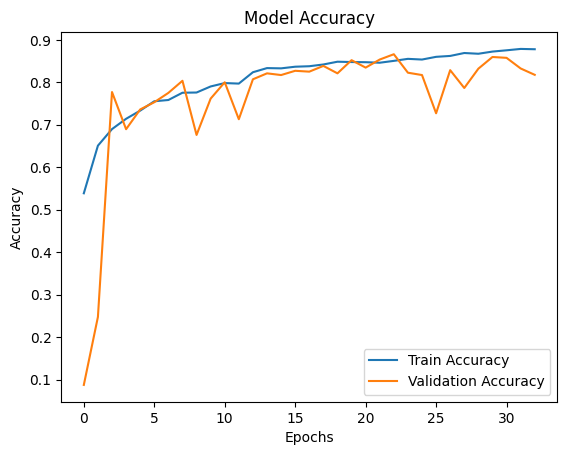

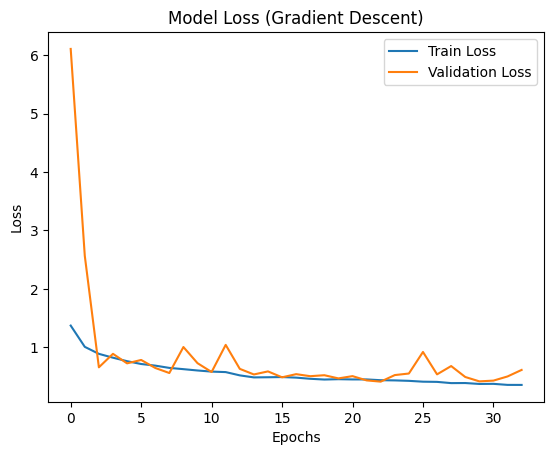

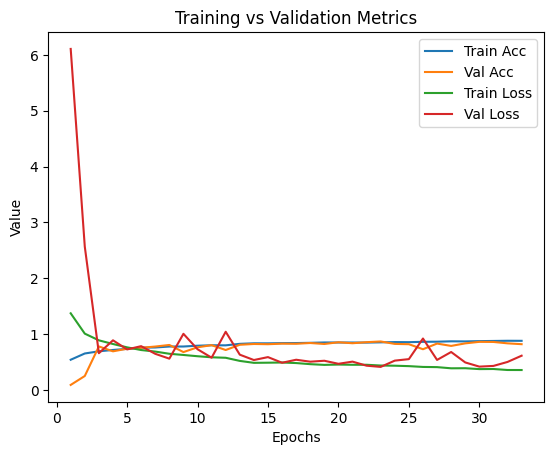

In [32]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Loss plot (this reflects gradient descent behavior)
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss (Gradient Descent)')
plt.show()

# # Overfitting visualization
# plt.figure()
# plt.plot(history.history['accuracy'], label='Train Acc')
# plt.plot(history.history['val_accuracy'], label='Val Acc')
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
# plt.legend()
# plt.title('Training vs Validation Metrics')
# plt.show()

# Overfitting visualization with epochs
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure()

plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')

plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.title('Training vs Validation Metrics')

plt.show()

Prediction Function

Model loaded successfully.


Saving AnnualCrop_3.jpg to AnnualCrop_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


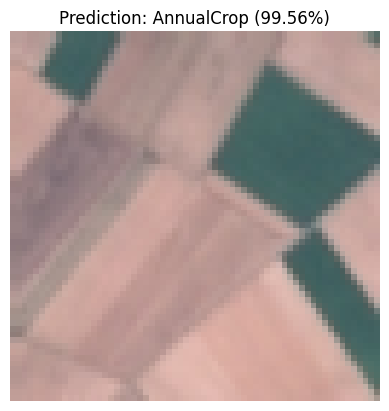

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# 1. Path to your saved model in Drive
model_path = '/content/drive/MyDrive/LandUseClassification_CNN/EuroSat_Model_86acc.keras'

def load_and_predict():
    # Load the model
    try:
        current_model = load_model(model_path)
        print("Model loaded successfully.")
    except Exception as e:
        print(f" Error loading model: {e}")
        return

    # Upload file
    from google.colab import files
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Preprocess to match training (64x64 and Normalized)
        img = image.load_img(filename, target_size=(64, 64))
        img_array = image.img_to_array(img) / 255.0
        img_input = np.expand_dims(img_array, axis=0)

        # Predict
        predictions = current_model.predict(img_input)
        class_idx = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions) * 100

        # Convert index to label name using your LabelEncoder 'le'
        # Ensure 'le' is defined in your current session!
        label = le.inverse_transform([class_idx])[0]

        # Display result
        plt.imshow(img)
        plt.title(f"Prediction: {label} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

# Run the predictor
load_and_predict()

Model loaded successfully.


Saving Highway_6.jpg to Highway_6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


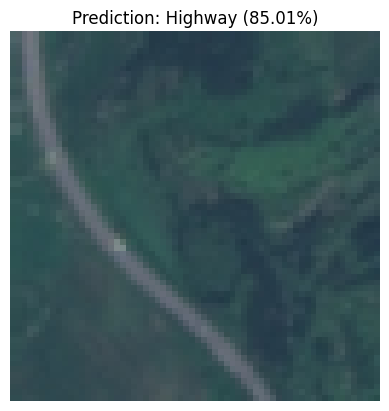

In [28]:
load_and_predict()

Model loaded successfully.


Saving River_1.jpg to River_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


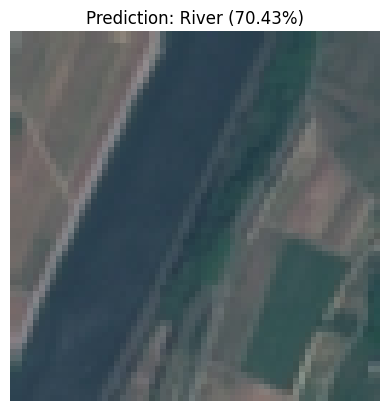

In [29]:
load_and_predict()

Model loaded successfully.


Saving River_8.jpg to River_8.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


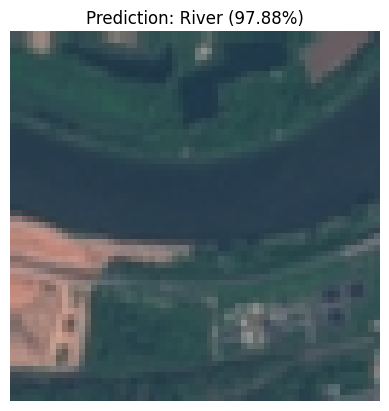

In [33]:
load_and_predict()

Model loaded successfully.


Saving River_2494.jpg to River_2494.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


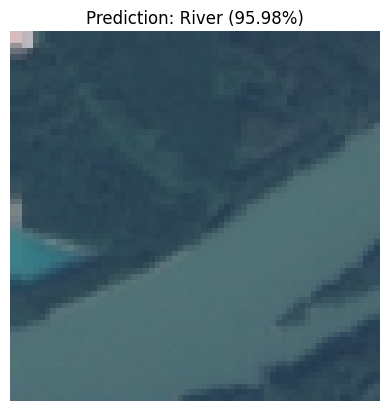

In [34]:
load_and_predict()

Model loaded successfully.


Saving PermanentCrop_3.jpg to PermanentCrop_3.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


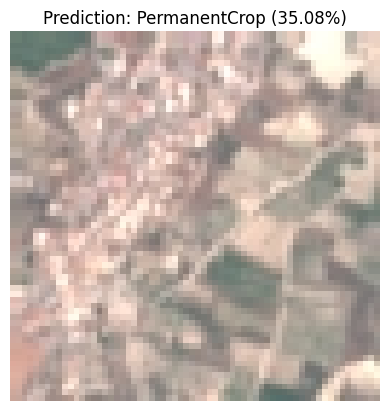

In [35]:
load_and_predict()

Model loaded successfully.


Saving PermanentCrop_29.jpg to PermanentCrop_29.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


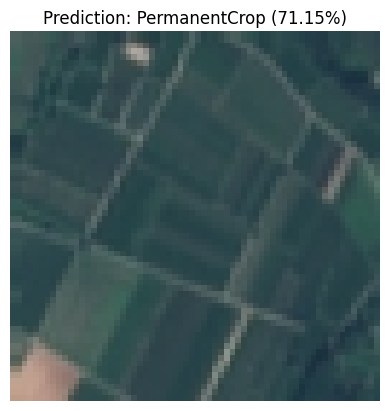

In [36]:
load_and_predict()

Model loaded successfully.


Saving Residential_1.jpg to Residential_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


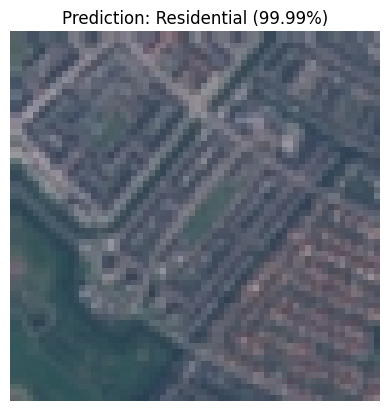

In [39]:
load_and_predict()

Model loaded successfully.


Saving Residential_27.jpg to Residential_27.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


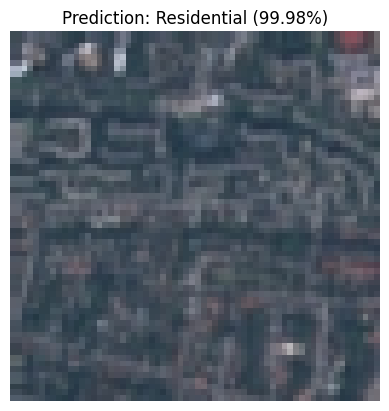

In [40]:
load_and_predict()

Model loaded successfully.


Saving Industrial_3.jpg to Industrial_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


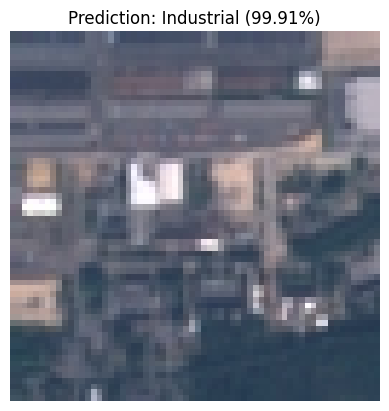

In [41]:
load_and_predict()

In [30]:
#further more improvement approach

# #Uses Transfer Learning (Pre=trained models)

# from tensorflow.keras.applications import ResNet50V2
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input

# # 1. Load the pre-trained ResNet50V2 model
# # include_top=False removes the final ImageNet classification layers
# base_model = ResNet50V2(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(64, 64, 3)
# )

# # 2. Freeze the base model
# # This prevents the pre-trained weights from being destroyed during initial training
# base_model.trainable = False

# # 3. Create the custom head
# inputs = Input(shape=(64, 64, 3))
# # ResNet50V2 expects inputs in range [-1, 1].
# # Since your X is already normalized [0, 1], we adjust it:
# x = (inputs * 2.0) - 1.0

# x = base_model(x, training=False)
# x = GlobalAveragePooling2D()(x)
# x = Dense(256, activation='relu')(x)
# x = Dropout(0.4)(x)
# outputs = Dense(len(np.unique(y_encoded)), activation='softmax')(x)

# model = Model(inputs, outputs)

# # 4. Compile
# model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# # 5. Train (The rest of your datagen.flow and fit logic remains the same)
# history = model.fit(
#     datagen.flow(X_train, y_train, batch_size=32),
#     epochs=25,
#     validation_data=(X_test, y_test),
#     callbacks=[early_stop, lr_reducer]
# )